In [36]:
import os
import pandas as pd
import seaborn as sns

import numpy as np
from matplotlib import pyplot as plt
import scipy

In [37]:
def heatmap(evaluation_results: pd.DataFrame, target_velocities: np.ndarray, delta: float = 0.25):
    evaluation_results_list = evaluation_results.to_dict("records")
    heatmap_values = list()

    for i in range(len(target_velocities) - 1):
        heatmap_values.append({
            "target_velocity": target_velocities[i],
            "stub_y": 1.0,
            "r": 0.0
        })

    for i in range(len(heatmap_values)):
        velocity_min = heatmap_values[i]["target_velocity"]
        velocity_max = velocity_min + delta

        rewards = list()
        for j in range(len(evaluation_results_list)):
            target_velocity = evaluation_results_list[j]["target_velocity"]
            r_eval = evaluation_results_list[j]["r"]

            if (velocity_min <= target_velocity < velocity_max):
                rewards.append(r_eval)
                pass

        heatmap_values[i]["r"] = np.mean(rewards)
    
    heatmap_values_df = pd.DataFrame.from_dict(heatmap_values)
    heatmap_values_df["target_velocity"] = heatmap_values_df["target_velocity"] + 0.25

    heatmap = heatmap_values_df.pivot(index="stub_y", columns=["target_velocity"], values="r")
    heatmap.sort_index(ascending=False, inplace=True)

    return heatmap

In [38]:
def merge_csvs_to_df(csv_paths: list) -> pd.DataFrame:
    merged_data = list()

    for csv in csv_paths: 
        temp = pd.read_csv(csv).to_dict("records")
        merged_data.extend(temp)
        pass

    return pd.DataFrame.from_records(merged_data)

In [39]:
# constants
max_target_velocity = 3.0
random_seeds = [2878, 5069, 5073, 5250, 4420]
target_velocities = np.linspace(0.0, max_target_velocity, num=31)

In [40]:
target_velocities

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
       2.6, 2.7, 2.8, 2.9, 3. ])

In [41]:
rl_squared_csvs = list()
auto_dr_csvs = list()

for seed in random_seeds:
    rl_squared_csvs.append(f"../data/rl_squared/max-3/seed-{seed}.csv")
    auto_dr_csvs.append(f"../data/auto_dr/max-3/seed-{seed}.csv")
    pass

In [42]:
rl_squared_results = merge_csvs_to_df(rl_squared_csvs)

# merge
merged_data = list()
for csv in rl_squared_csvs:
    temp = pd.read_csv(csv).to_dict("records")
    merged_data.extend(temp)
    break

In [43]:
rl_squared_results["target_velocity"] = rl_squared_results["target_velocity"].str.removeprefix("[")
rl_squared_results["target_velocity"] = rl_squared_results["target_velocity"].str.removesuffix("]")
rl_squared_results["target_velocity"] = rl_squared_results["target_velocity"].astype(float).round(2)

In [48]:
rl_squared_results["target_velocity"]

0        0.05
1        0.08
2        0.11
3        0.14
4        0.17
         ... 
49995    2.88
49996    2.91
49997    2.94
49998    2.97
49999    3.00
Name: target_velocity, Length: 50000, dtype: float64

In [49]:
rl_squared_heatmap = heatmap(rl_squared_results, target_velocities,  0.25)

In [50]:
rl_squared_heatmap.columns

Index([              0.25,               0.35,               0.45,
                     0.55,               0.65,               0.75,
       0.8500000000000001, 0.9500000000000001,               1.05,
                     1.15,               1.25,               1.35,
       1.4500000000000002,               1.55, 1.6500000000000001,
                     1.75,               1.85, 1.9500000000000002,
                     2.05, 2.1500000000000004,               2.25,
                     2.35,               2.45, 2.5500000000000003,
       2.6500000000000004,               2.75,               2.85,
                     2.95, 3.0500000000000003, 3.1500000000000004],
      dtype='float64', name='target_velocity')

In [52]:
new_columns = list()
for col in rl_squared_heatmap.columns:
    new_columns.append(str(round(float(col), 2)))

In [54]:
rl_squared_heatmap.columns = new_columns

<Axes: ylabel='stub_y'>

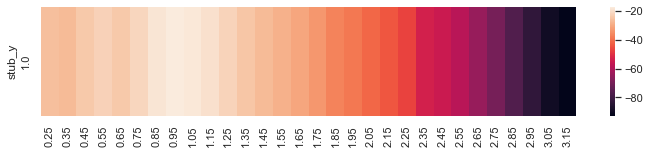

In [55]:
sns.set (rc = {'figure.figsize':(12, 2)})
sns.heatmap(rl_squared_heatmap, fmt='.4f')